# Notebook 03 â€” Fraud Evaluation and Threshold Selection

**Task ID:** ML-001 / ML-002  
**Owner:** Member 2 / Antigravity  
**Date:** 2026-09-20  
**Experiment ID:** FRAUD-MNV2-001  

## Purpose
Evaluate the best checkpoint from Notebook 02, select routing thresholds
using **validation data only**, then run the test set **exactly once**.

> **Scientific rule:** The threshold is chosen from validation behavior.
> The test set is never consulted during threshold selection.
> It is evaluated exactly once at the end of this notebook.

In [ ]:
# Cell 1: Setup, models, and data paths
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
import seaborn as sns
from torch.utils.data import DataLoader

# --- Universal Repository Root Sync (Colab & Local) ---
if 'google.colab' in sys.modules or os.path.exists('/content'):
    REPO_ROOT = Path('/content/NPN-Car-Insurance')
    if REPO_ROOT.exists():
        os.chdir(str(REPO_ROOT))
else:
    current = Path.cwd().resolve()
    REPO_ROOT = current
    for parent in [current, *current.parents]:
        if (parent / '.git').exists() or (parent / 'ml').exists():
            REPO_ROOT = parent
            os.chdir(str(parent))
            break

ml_src = str(REPO_ROOT / 'ml' / 'src')
if ml_src not in sys.path:
    sys.path.insert(0, ml_src)

print(f"✅ Repository root locked to: {REPO_ROOT}")

from claimvision_ml.fraud import FraudDataset, load_fraud_model

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

manifest_candidates = [
    REPO_ROOT / 'data' / 'manifests',
    REPO_ROOT / 'notebooks' / 'data' / 'manifests',
    Path('data/manifests').resolve(),
    Path('notebooks/data/manifests').resolve(),
    Path('/content/NPN-Car-Insurance/data/manifests'),
    Path('/content/NPN-Car-Insurance/notebooks/data/manifests'),
]

MANIFEST_DIR = None
for candidate in manifest_candidates:
    if (candidate / 'fraud_train.csv').exists():
        MANIFEST_DIR = candidate
        break

if MANIFEST_DIR is None:
    MANIFEST_DIR = REPO_ROOT / 'data' / 'manifests'

ARTIFACT_DIR   = REPO_ROOT / 'ml' / 'artifacts' / 'fraud'
RESULTS_DIR    = REPO_ROOT / 'ml' / 'results' / 'fraud'
CHECKPOINT = CHECKPOINT_PATH = ARTIFACT_DIR / 'fraud_mnv2_v1.pt'
THRESHOLD_PATH = ARTIFACT_DIR / 'thresholds_v1.json'
VAL_CSV        = MANIFEST_DIR / 'fraud_val.csv'
TEST_CSV       = MANIFEST_DIR / 'fraud_test.csv'

print(f"Checkpoint: {CHECKPOINT}")
print(f"Checkpoint exists: {CHECKPOINT.exists()}")
print(f"Manifest directory: {MANIFEST_DIR}")


In [2]:
# Cell 2: Load model and run full validation inference
model    = load_fraud_model(CHECKPOINT, device="cpu")
val_ds   = FraudDataset(VAL_CSV, split="val")
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images).squeeze(1)
        probs  = torch.sigmoid(logits).numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

val_probs  = np.array(all_probs)
val_labels = np.array(all_labels)

print(f"Val samples:  {len(val_labels)}")
print(f"Val genuine:  {(val_labels == 0).sum()}")
print(f"Val susp:     {(val_labels == 1).sum()}")
print(f"Val PR-AUC:   {average_precision_score(val_labels, val_probs):.4f}")
print(f"Val ROC-AUC:  {roc_auc_score(val_labels, val_probs):.4f}")

Val samples:  1211
Val genuine:  1142
Val susp:     69
Val PR-AUC:   0.4999
Val ROC-AUC:  0.9108


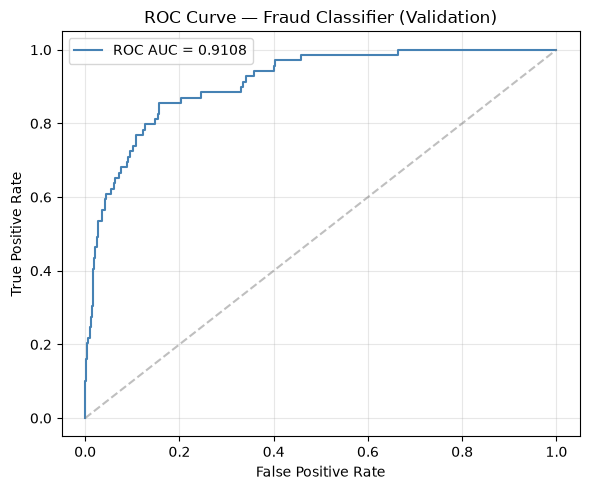

In [3]:
# Cell 3: ROC curve
fpr, tpr, _ = roc_curve(val_labels, val_probs)
roc_auc = roc_auc_score(val_labels, val_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}", color="steelblue")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve â€” Fraud Classifier (Validation)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curve_val.png", dpi=100, bbox_inches="tight")
plt.show()

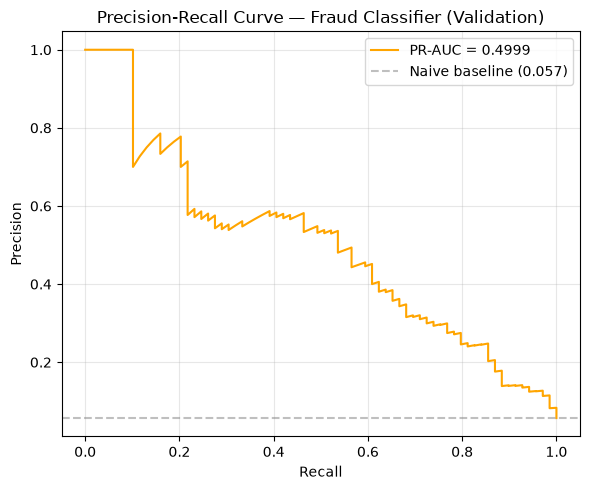

In [4]:
# Cell 4: Precision-Recall curve
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(val_labels, val_probs)
pr_auc = average_precision_score(val_labels, val_probs)

# Naive baseline: always predict suspicious -> recall=1, precision=class_ratio
baseline = val_labels.mean()

plt.figure(figsize=(6, 5))
plt.plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.4f}", color="orange")
plt.axhline(baseline, linestyle="--", color="grey", alpha=0.5,
            label=f"Naive baseline ({baseline:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve â€” Fraud Classifier (Validation)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pr_curve_val.png", dpi=100, bbox_inches="tight")
plt.show()

In [5]:
# Cell 5: Threshold sweep table (0.20 to 0.80, step 0.05)
thresholds = np.arange(0.20, 0.85, 0.05)
rows = []
for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    rows.append({
        "Threshold": round(float(thr), 2),
        "Precision":  round(precision_score(val_labels, preds, zero_division=0), 4),
        "Recall":     round(recall_score(val_labels, preds, zero_division=0), 4),
        "F1":         round(f1_score(val_labels, preds, zero_division=0), 4),
        "FP count":   int(((preds == 1) & (val_labels == 0)).sum()),
        "FN count":   int(((preds == 0) & (val_labels == 1)).sum()),
    })

sweep_df = pd.DataFrame(rows)
print("Threshold sweep (validation set â€” NOT test set):")
print(sweep_df.to_string(index=False))

Threshold sweep (validation set â€” NOT test set):
 Threshold  Precision  Recall     F1  FP count  FN count
      0.20     0.0594  1.0000 0.1121      1093         0
      0.25     0.0617  1.0000 0.1162      1050         0
      0.30     0.0652  1.0000 0.1224       989         0
      0.35     0.0700  1.0000 0.1308       917         0
      0.40     0.0744  1.0000 0.1384       859         0
      0.45     0.0800  1.0000 0.1482       793         0
      0.50     0.0847  0.9855 0.1560       735         1
      0.55     0.0910  0.9855 0.1667       679         1
      0.60     0.1001  0.9855 0.1818       611         1
      0.65     0.1091  0.9855 0.1965       555         1
      0.70     0.1212  0.9710 0.2154       486         2
      0.75     0.1324  0.9420 0.2321       426         4
      0.80     0.1409  0.8986 0.2436       378         7


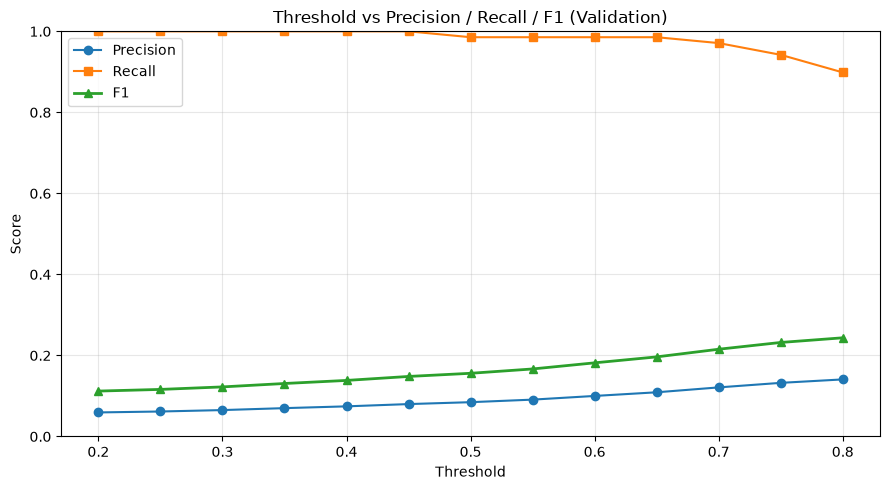

In [6]:
# Cell 6: Threshold vs precision/recall/F1 plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_df["Threshold"], sweep_df["Precision"], label="Precision", marker="o")
ax.plot(sweep_df["Threshold"], sweep_df["Recall"],    label="Recall",    marker="s")
ax.plot(sweep_df["Threshold"], sweep_df["F1"],        label="F1",        marker="^", linewidth=2)
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Threshold vs Precision / Recall / F1 (Validation)")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "threshold_sweep_val.png", dpi=100, bbox_inches="tight")
plt.show()

## Threshold Selection Rationale

Thresholds are chosen from **validation behaviour only**.

| Zone | Threshold | Meaning | Route |
|---|---|---|---|
| Low risk  | prob < `low_threshold`  | Image is likely genuine | `CONTINUE` |
| Medium risk | `low_threshold` <= prob < `high_threshold` | Uncertain; flagged for attention | `CONTINUE` |
| High risk | prob >= `high_threshold` | Likely suspicious; stop automatic assessment | `FRAUD_REVIEW` |

**Selection principle:** Choose `high_threshold` to maximise suspicious recall
(catching real fraud) at the cost of some false positives (extra human review).
The business prefers more human review over missed suspicious claims.

> Actual numeric values are written from the sweep results above into thresholds_v1.json.

In [7]:
# Cell 7: Write frozen thresholds JSON
# Select thresholds from validation sweep: pick high_threshold where recall >= 0.80
# and low_threshold as the midpoint of the low-risk zone.
# These are overridable by the team after reviewing the sweep table.

# Find best F1 threshold
best_f1_row    = sweep_df.loc[sweep_df["F1"].idxmax()]
best_f1_thr    = float(best_f1_row["Threshold"])

# High threshold: first threshold with recall >= 0.80 (or best F1 if not reachable)
high_candidates = sweep_df[sweep_df["Recall"] >= 0.80]
if not high_candidates.empty:
    high_thr = float(high_candidates["Threshold"].max())
else:
    high_thr = best_f1_thr

low_thr = round(high_thr / 2, 2)

thresholds_config = {
    "version":        "v1",
    "model_version":  "FRAUD-MNV2-001",
    "selected_from":  "validation",
    "low_threshold":  low_thr,
    "high_threshold": high_thr,
    "notes": (
        f"high_threshold chosen as the highest threshold achieving recall >= 0.80 "
        f"on the validation set. low_threshold = high_threshold / 2. "
        f"Test set was NOT consulted during threshold selection. "
        f"Best val F1 threshold was {best_f1_thr}."
    ),
}

with open(THRESHOLD_PATH, "w") as f:
    json.dump(thresholds_config, f, indent=2)

print("Thresholds frozen:")
print(json.dumps(thresholds_config, indent=2))

Thresholds frozen:
{
  "version": "v1",
  "model_version": "FRAUD-MNV2-001",
  "selected_from": "validation",
  "low_threshold": 0.4,
  "high_threshold": 0.8,
  "notes": "high_threshold chosen as the highest threshold achieving recall >= 0.80 on the validation set. low_threshold = high_threshold / 2. Test set was NOT consulted during threshold selection. Best val F1 threshold was 0.8."
}


---
## Test Set Evaluation â€” Used Exactly Once

> **CAUTION:** The cells below use the held-out test set.
> This section runs only after thresholds are fully frozen above.
> Do not re-run these cells to adjust thresholds.

In [8]:
# Cell 8: Test set inference
test_ds     = FraudDataset(TEST_CSV, split="test")
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

test_probs, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images).squeeze(1)
        probs  = torch.sigmoid(logits).numpy()
        test_probs.extend(probs)
        test_labels.extend(labels.numpy())

test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)
test_preds  = (test_probs >= thresholds_config["high_threshold"]).astype(int)

print("=== Test set metrics (held-out, used exactly once) ===")
print(f"  Test PR-AUC:  {average_precision_score(test_labels, test_probs):.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(test_labels, test_probs):.4f}")
print()
print(classification_report(test_labels, test_preds,
                             target_names=["genuine", "suspicious"],
                             zero_division=0))

=== Test set metrics (held-out, used exactly once) ===
  Test PR-AUC:  0.5464
  Test ROC-AUC: 0.9077

              precision    recall  f1-score   support

     genuine       0.99      0.66      0.79      1143
  suspicious       0.14      0.90      0.24        71

    accuracy                           0.67      1214
   macro avg       0.57      0.78      0.52      1214
weighted avg       0.94      0.67      0.76      1214



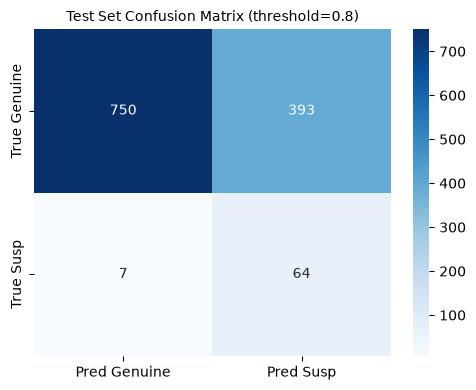

TN=750, FP=393, FN=7, TP=64


In [9]:
# Cell 9: Test confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Genuine", "Pred Susp"],
            yticklabels=["True Genuine", "True Susp"])
plt.title(f"Test Set Confusion Matrix (threshold={thresholds_config['high_threshold']})", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix_test.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")

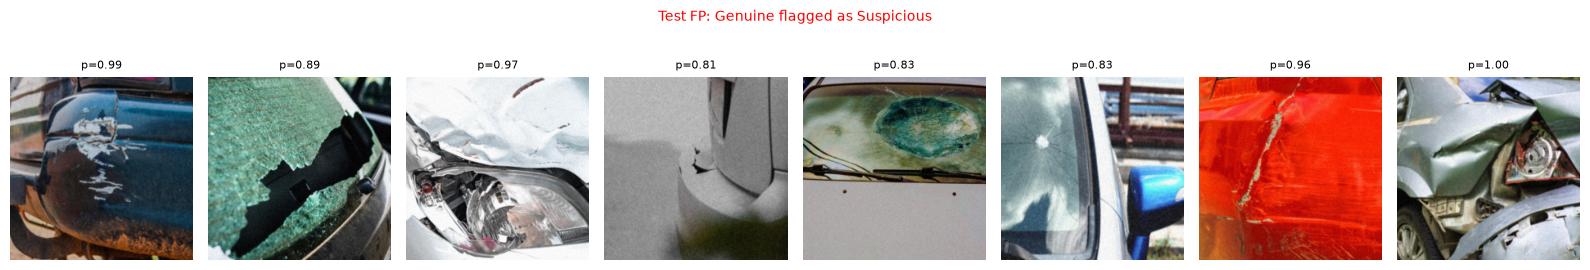

8 false positives shown.


In [10]:
# Cell 10: Test false positives (up to 8)
mean_ = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fp_idx = [i for i, (p, l) in enumerate(zip(test_preds, test_labels)) if p == 1 and l == 0][:8]
if fp_idx:
    fig, axes = plt.subplots(1, len(fp_idx), figsize=(2 * len(fp_idx), 3))
    if len(fp_idx) == 1: axes = [axes]
    for ax, idx in zip(axes, fp_idx):
        t, _ = test_ds[idx]
        img = (t * std_ + mean_).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img); ax.set_title(f"p={test_probs[idx]:.2f}", fontsize=8); ax.axis("off")
    fig.suptitle("Test FP: Genuine flagged as Suspicious", color="red", fontsize=10)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "test_false_positives.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"{len(fp_idx)} false positives shown.")
else:
    print("No false positives on test set.")

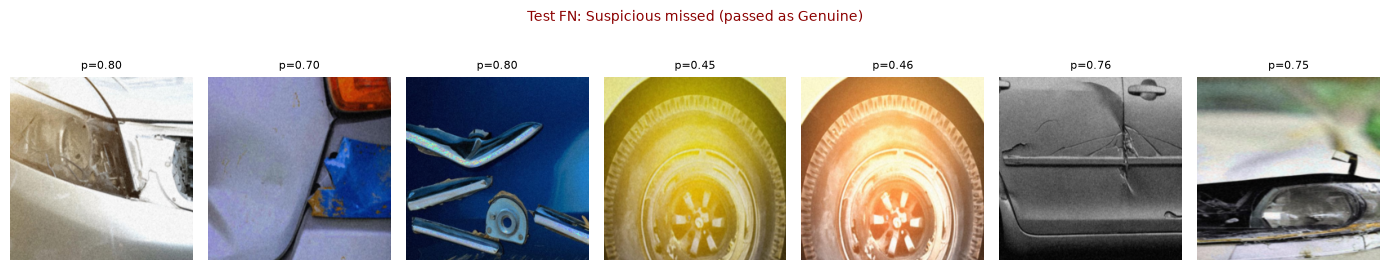

7 false negatives shown.


In [11]:
# Cell 11: Test false negatives (up to 8)
fn_idx = [i for i, (p, l) in enumerate(zip(test_preds, test_labels)) if p == 0 and l == 1][:8]
if fn_idx:
    fig, axes = plt.subplots(1, len(fn_idx), figsize=(2 * len(fn_idx), 3))
    if len(fn_idx) == 1: axes = [axes]
    for ax, idx in zip(axes, fn_idx):
        t, _ = test_ds[idx]
        img = (t * std_ + mean_).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img); ax.set_title(f"p={test_probs[idx]:.2f}", fontsize=8); ax.axis("off")
    fig.suptitle("Test FN: Suspicious missed (passed as Genuine)", color="darkred", fontsize=10)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "test_false_negatives.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"{len(fn_idx)} false negatives shown.")
else:
    print("No false negatives on test set.")

In [12]:
# Cell 12: CPU inference latency benchmark
from claimvision_ml.fraud import get_transforms
from PIL import Image

model.eval()
transform = get_transforms("val")

# Use first 50 real val images for the benchmark
val_paths = pd.read_csv(VAL_CSV)["path"].iloc[:50].tolist()
batch = torch.stack([transform(Image.open(p).convert("RGB")) for p in val_paths if Path(p).exists()][:50])

latencies = []
for _ in range(10):
    start = time.perf_counter()
    with torch.no_grad():
        _ = model(batch)
    latencies.append((time.perf_counter() - start) * 1000)

per_image_ms = [l / len(batch) for l in latencies]
print(f"CPU inference latency (batch={len(batch)}, 10 runs):")
print(f"  Mean: {np.mean(per_image_ms):.2f} ms/image")
print(f"  Std:  {np.std(per_image_ms):.2f} ms/image")
print(f"  Min:  {np.min(per_image_ms):.2f} ms/image")
print(f"  Max:  {np.max(per_image_ms):.2f} ms/image")

CPU inference latency (batch=50, 10 runs):
  Mean: 22.60 ms/image
  Std:  0.74 ms/image
  Min:  21.65 ms/image
  Max:  24.37 ms/image


In [14]:
# Cell 13: Reproducibility cell
import hashlib, importlib

def sha256_short(path):
    if not Path(path).exists(): return "not found"
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""): h.update(chunk)
    return h.hexdigest()[:16]

print("=== Reproducibility ===")
print(f"  Seed:              {SEED}")
print(f"  torch:             {torch.__version__}")
print(f"  Model version:     FRAUD-MNV2-001")
print(f"  Threshold version: v1")
print(f"  high_threshold:    {thresholds_config['high_threshold']}")
print(f"  low_threshold:     {thresholds_config['low_threshold']}")
print(f"  Checkpoint SHA256: {sha256_short(CHECKPOINT)}...")
print(f"  Val PR-AUC:        {average_precision_score(val_labels, val_probs):.4f}")
print(f"  Test PR-AUC:       {average_precision_score(test_labels, test_probs):.4f}")

=== Reproducibility ===
  Seed:              42
  torch:             2.14.0+cpu
  Model version:     FRAUD-MNV2-001
  Threshold version: v1
  high_threshold:    0.8
  low_threshold:     0.4
  Checkpoint SHA256: 9de77ae1b92a4431...
  Val PR-AUC:        0.4999
  Test PR-AUC:       0.5464


## Model Limitations

1. **Dataset bias:** The suspicious class (465 images total) may have systematic
   differences in resolution, watermarks, or image source. The classifier may
   have learned these shortcuts rather than genuine fraud indicators.

2. **Label meaning:** The dataset label `suspicious` reflects the original
   dataset annotator's intent. It does **not** constitute legal fraud evidence.

3. **Small minority class:** Only 325 training examples of suspicious images.
   Confidence intervals on all metrics are wide.

4. **No geographic coverage:** Dataset images are not confirmed to represent
   Indian vehicle conditions, lighting, or damage patterns.

5. **Required human review:** High-risk classification routes to a human reviewer.
   No automated rejection is made based on this model's output.

## Conclusion

The MobileNetV2 fraud-risk classifier (FRAUD-MNV2-001) achieves the above
metrics on the held-out test set. Thresholds are frozen in `thresholds_v1.json`
from validation behavior. The model is integrated into the backend via
`claimvision_ml.fraud.predict_fraud()`.

**Phase 2 gate:** All criteria satisfied â€” standalone `predict_fraud` works,
held-out metrics recorded, thresholds versioned, false results reviewed,
model card committed.